# 05 — Full Evaluation and Error Analysis

Evaluates the trained Tiny Transformer on the **full** filtered test set (8,491) and
analyses its errors. Greedy decoding, BLEU/chrF++ scoring and the error categories are all
implemented here; only the model class (`src/model.py`, built in notebook 04) and the
SentencePiece vocab loader (`src/vocab.py`) are imported.

## Setup

In [1]:
import os, sys, time
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")

import torch
torch.set_num_threads(os.cpu_count() or 1)
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu
import sentencepiece as spm
from model import TinyTransformerMT      # architecture, defined/explained in notebook 04
from vocab import load_vocab             # loads SentencePiece .vocab -> ids

TOK, VOC = "Data/tokenized", "Data/vocab"
MAX_LEN = 80
sp_en = spm.SentencePieceProcessor(model_file=f"{VOC}/sp_en.model")
sp_ar = spm.SentencePieceProcessor(model_file=f"{VOC}/sp_ar.model")

## Load the trained model
We rebuild the same tiny architecture and load the best checkpoint (epoch 40).

In [2]:
src_vocab = load_vocab(f"{VOC}/sp_ar.vocab")
tgt_vocab = load_vocab(f"{VOC}/sp_en.vocab")
ARCH = dict(d_model=128, nhead=4, num_encoder_layers=2, num_decoder_layers=2,
            dim_feedforward=512, dropout=0.1)
model = TinyTransformerMT(len(src_vocab), len(tgt_vocab), src_vocab.pad_id, tgt_vocab.pad_id,
                          max_len=MAX_LEN + 2, **ARCH)
ckpt = torch.load("outputs/checkpoints/best_full_model.pt", map_location="cpu", weights_only=False)
model.load_state_dict(ckpt.get("model_state_dict") or ckpt["model_state"])
model.eval()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"loaded epoch {ckpt['epoch']} | best_val_loss {ckpt['best_val_loss']:.4f} | params {n_params:,}")

loaded epoch 40 | best_val_loss 4.0166 | params 4,006,208


## Load + filter the test set, and small scoring helpers

In [3]:
def read_lines(p):
    return open(p, encoding="utf-8").read().splitlines()

pairs = [(a, e) for a, e in zip(read_lines(f"{TOK}/test.ar.bpe"), read_lines(f"{TOK}/test.en.bpe"))
         if len(a.split()) <= MAX_LEN and len(e.split()) <= MAX_LEN]
test_ar = [a for a, e in pairs]
reference = [sp_en.decode(e.split()) for a, e in pairs]   # true detokenized references
print(f"test pairs kept: {len(pairs):,}")

def score(hyp, ref):
    return (sacrebleu.corpus_bleu(hyp, [ref]).score,
            sacrebleu.corpus_chrf(hyp, [ref], word_order=2).score)

test pairs kept: 8,491


## Greedy decoding (implemented here)
Autoregressive: start from `<s>`, repeatedly take the arg-max next token and feed it back
until `</s>` or `max_len`. Padded once a sentence finishes.

In [4]:
@torch.no_grad()
def greedy_decode(model, src, bos, eos, pad, max_len=80):
    ys = torch.full((src.size(0), 1), bos, dtype=torch.long)
    done = torch.zeros(src.size(0), dtype=torch.bool)
    for _ in range(max_len):
        nxt = model(src, ys)[:, -1].argmax(-1)        # most likely next token
        nxt = nxt.masked_fill(done, pad)
        ys = torch.cat([ys, nxt.unsqueeze(1)], dim=1)
        done |= nxt.eq(eos)
        if done.all():
            break
    return ys

def encode_batch(bpe_lines, vocab):
    ids = [vocab.encode_pieces(l.split(), add_bos=True, add_eos=True) for l in bpe_lines]
    width = max(len(x) for x in ids)
    batch = torch.full((len(ids), width), vocab.pad_id, dtype=torch.long)
    for r, seq in enumerate(ids):
        batch[r, :len(seq)] = torch.tensor(seq)
    return batch

# quick demo on 3 sentences so the function is visibly exercised
demo = greedy_decode(model, encode_batch(test_ar[:3], src_vocab),
                     tgt_vocab.bos_id, tgt_vocab.eos_id, tgt_vocab.pad_id, MAX_LEN)
for i in range(3):
    print("hyp:", sp_en.decode(tgt_vocab.decode_ids(demo[i].tolist(), stop_at_eos=True)))

D:\Ahmed Sherif\Digilians\Deep Learning\Project\Low-Resource Machine Translation with Tiny Transformers\.venv\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


hyp: the adoption of us have been here, a few years ago, a lot of us have been a solution for a solution for a solution for a solution for a solution for a solution for a solution for a solution for a solution.
hyp: and one of the most famous bricker, one of the most famous bricker, one of the most famous bricker, one of the most famous bricker, the most famous bricker of the most famous bricker.
hyp: the top of the top of the top of the top.


## Decode the full test set
Batches of 32 on CPU (~8 minutes). This is the same procedure mirrored in
`scripts/run_full_eval.py` for one-command reproduction.

In [5]:
t0 = time.time()
hyp = []
BATCH = 32
for i in range(0, len(test_ar), BATCH):
    out = greedy_decode(model, encode_batch(test_ar[i:i + BATCH], src_vocab),
                        tgt_vocab.bos_id, tgt_vocab.eos_id, tgt_vocab.pad_id, MAX_LEN)
    for row in out.tolist():
        hyp.append(sp_en.decode(tgt_vocab.decode_ids(row, stop_at_eos=True)))
print(f"decoded {len(hyp)} sentences in {(time.time()-t0)/60:.1f} min")

decoded 8491 sentences in 8.4 min


## Full-test results vs the baseline
Baseline numbers come from notebook 03 (`baseline_results.csv`).

In [6]:
bleu_full, chrf_full = score(hyp, reference)
base = pd.read_csv("outputs/tables/baseline_results.csv").iloc[0]
results = pd.DataFrame([
    {"model": "dictionary_position_baseline", "decoding": "position_dictionary",
     "examples": len(hyp), "bleu": round(base.bleu, 4), "chrf_pp": round(base.chrf_pp, 4)},
    {"model": "tiny_transformer_best", "decoding": "greedy",
     "examples": len(hyp), "bleu": round(bleu_full, 4), "chrf_pp": round(chrf_full, 4)},
])
results.to_csv("outputs/tables/full_test_bleu_results.csv", index=False)
pd.DataFrame({"sample_id": range(len(hyp)),
              "source_ar": [sp_ar.decode(a.split()) for a in test_ar],
              "reference_en": reference, "transformer_output": hyp,
              "source_length": [len(sp_ar.decode(a.split()).split()) for a in test_ar],
              "target_length": [len(r.split()) for r in reference]}
             ).to_csv("outputs/examples/full_test_predictions.csv", index=False, encoding="utf-8")
results

,model,decoding,examples,bleu,chrf_pp
0,dictionary_position_baseline,position_dictionary,8491,4.7777,25.6503
1,tiny_transformer_best,greedy,8491,6.2172,24.6435


### 1,000-subset vs full test (sampling variance)

In [7]:
bleu_1k, chrf_1k = score(hyp[:1000], reference[:1000])
svf = pd.DataFrame([
    {"model": "tiny_transformer_best", "bleu_1000": round(bleu_1k, 4), "bleu_full": round(bleu_full, 4),
     "delta_bleu": round(bleu_full - bleu_1k, 4), "chrf_1000": round(chrf_1k, 4), "chrf_full": round(chrf_full, 4)},
])
svf.to_csv("outputs/tables/sample_vs_full_eval.csv", index=False)
svf

,model,bleu_1000,bleu_full,delta_bleu,chrf_1000,chrf_full
0,tiny_transformer_best,6.2399,6.2172,-0.0227,24.2011,24.6435


## Training / validation loss curves
From the saved 40-epoch log. Validation loss is still falling at the last epoch (undertrained).

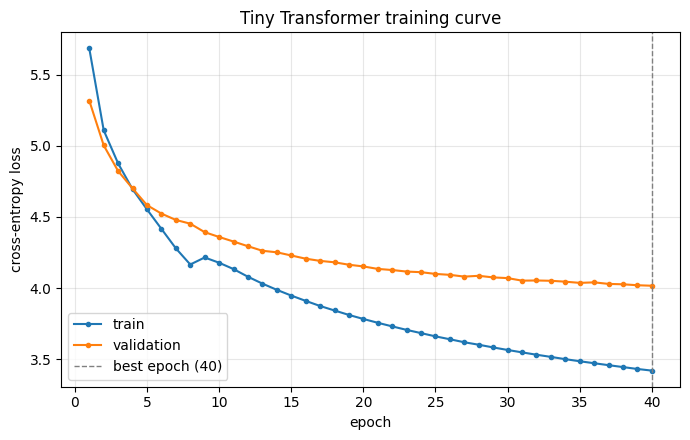

In [8]:
log = pd.read_csv("outputs/tables/full_training_log.csv")
best_epoch = int(log.loc[log["val_loss"].idxmin(), "epoch"])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(log.epoch, log.train_loss, marker="o", ms=3, label="train")
ax.plot(log.epoch, log.val_loss, marker="o", ms=3, label="validation")
ax.axvline(best_epoch, color="grey", ls="--", lw=1, label=f"best epoch ({best_epoch})")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss"); ax.set_title("Tiny Transformer training curve")
ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig("outputs/figures/train_val_loss_curve.png", dpi=200); plt.show()

## BLEU and chrF++ comparison

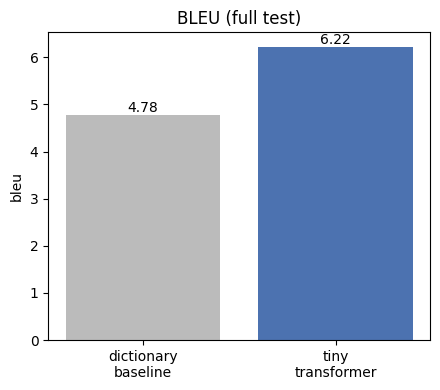

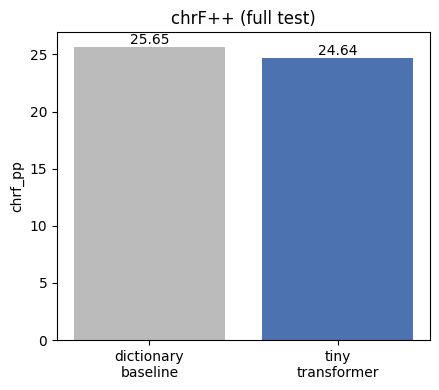

In [9]:
labels = ["dictionary\nbaseline", "tiny\ntransformer"]
for metric, fname, title in [("bleu", "main_bleu_comparison.png", "BLEU (full test)"),
                             ("chrf_pp", "main_chrf_comparison.png", "chrF++ (full test)")]:
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.bar_label(ax.bar(labels, results[metric], color=["#bbb", "#4c72b0"]), fmt="%.2f")
    ax.set_ylabel(metric); ax.set_title(title)
    fig.tight_layout(); fig.savefig(f"outputs/figures/{fname}", dpi=200); plt.show()

## Error analysis
Simple **automatic** categories (a first pass, to be reviewed by hand). Word-order and
named-entity errors need human judgement and are not auto-labelled.

In [10]:
def has_repetition(text):
    toks = text.split()
    if len(toks) < 4:
        return False
    bigrams = list(zip(toks, toks[1:]))
    return (len(bigrams) - len(set(bigrams)) >= 2) or (len(set(toks)) / len(toks) < 0.5)

def error_category(ref, hyp):
    r, h = ref.split(), hyp.split()
    if not any(ch.isalpha() for ch in hyp):
        return "empty/degenerate"
    if has_repetition(hyp):
        return "repetition"
    if len(h) > 1.8 * max(1, len(r)):
        return "over-generation"
    if len(h) < 0.5 * len(r):
        return "severe omission"
    if len(set(h) & set(r)) / max(1, len(set(r))) < 0.2:
        return "low overlap"
    return "adequate"

preds = pd.read_csv("outputs/examples/full_test_predictions.csv")
preds["transformer_output"] = preds["transformer_output"].fillna("")
preds["error_category"] = [error_category(r, h) for r, h in zip(preds.reference_en, preds.transformer_output)]
counts = preds["error_category"].value_counts()
counts.rename_axis("error_category").reset_index(name="count").to_csv(
    "outputs/tables/error_category_counts.csv", index=False)
counts

error_category
repetition          4228
adequate            2801
low overlap         1172
severe omission      194
over-generation       95
empty/degenerate       1
Name: count, dtype: int64

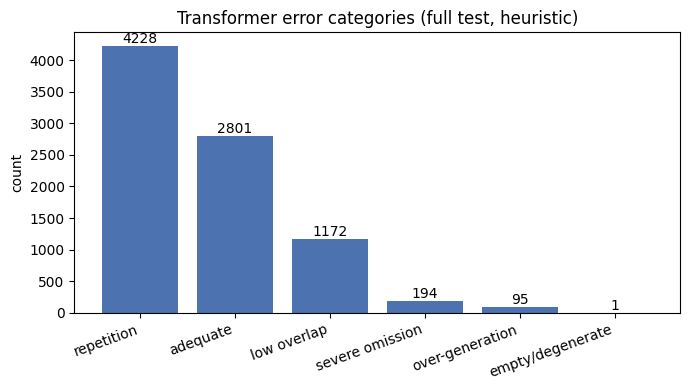

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar_label(ax.bar(counts.index, counts.values, color="#4c72b0"))
ax.set_ylabel("count"); ax.set_title("Transformer error categories (full test, heuristic)")
plt.xticks(rotation=20, ha="right"); fig.tight_layout()
fig.savefig("outputs/figures/error_category_distribution.png", dpi=200); plt.show()

### Stratified qualitative examples (50)
Spread across short/medium/long sources and worst/middle/best by sentence chrF, plus repetition cases.

In [12]:
preds["sent_chrf"] = [sacrebleu.sentence_chrf(h, [r]).score
                      for h, r in zip(preds.transformer_output, preds.reference_en)]
preds["len_bucket"] = pd.cut(preds.source_length, [0, 7, 18, 10_000], labels=["short", "medium", "long"])
picks = []
for b in ["short", "medium", "long"]:
    sub = preds[preds.len_bucket == b].sort_values("sent_chrf")
    if len(sub) >= 12:
        m = len(sub) // 2
        picks += list(sub.index[:4]) + list(sub.index[m - 2:m + 2]) + list(sub.index[-4:])
    else:
        picks += list(sub.index)
for i in preds[preds.error_category == "repetition"].index:
    if i not in picks: picks.append(i)
    if len(picks) >= 50: break
qual = preds.loc[picks[:50], ["sample_id", "source_ar", "reference_en", "transformer_output",
                              "error_category", "source_length", "target_length"]]
qual.to_csv("outputs/examples/qualitative_50_samples.csv", index=False, encoding="utf-8")
print(f"saved {len(qual)} samples")
qual.head(8)[["reference_en", "transformer_output", "error_category"]]

saved 50 samples


,reference_en,transformer_output,error_category
2025,explore.,it's a bit.,over-generation
7357,dwarves became columns.,the size of the size of the size of the size o...,repetition
769,no kidding.,yes.,low overlap
8246,"i'll be okay. please don't worry.""","no, no, no, no, no.",repetition
8225,girls were prohibited from going to school.,i went to school.,adequate
7223,"well, the name baker doesn't actually mean any...","well, don't mean something that's something.",adequate
4362,"i looked at his throat, it was a little bit pink.",and i looked at the top of my owner.,adequate
3849,for a year we were penniless.,we've been a year for two years.,adequate


## Notes
- Transformer (greedy) beats the baseline on BLEU but not chrF++; ~half the outputs repeat.
- BLEU barely moves between the 1,000 subset and the full test (representative subset).
- See `report_notes/` for the written interpretation; beam search (notebook 06) improves BLEU.